# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmedali3ff/Flyrank-internship-/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
import os
import subprocess
import pandas as pd
import numpy as np

REPO_DIR = "/content/Flyrank-internship-"
REPO_URL = "https://github.com/Ahmedali3ff/Flyrank-internship-.git"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

DATA_PATH = os.path.join(
        REPO_DIR,
            "data/raw/content_refresh_anonymized.csv"
            )

df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (30000, 44)


## 1. Distributions

Before testing individual signals, inspect the distributions of the main fields used in the audit.

The dataset contains several performance and age variables with potentially skewed or heavy-tailed distributions. For this reason, both summary statistics and robust measures such as the median are considered.

The audit focuses on search position, recent impressions, recent sessions, content age, and update recency.


avg_position
count    30000.00000
mean        16.34238
std         15.21679
min          0.00000
25%          6.20000
50%         10.80000
75%         22.30000
max        245.00000
Name: avg_position, dtype: float64
Skew: 1.9842143239597732

impressions_last_30d
count     30000.000000
mean       1429.058733
std        5643.852081
min           0.000000
25%          10.000000
50%         139.000000
75%         768.000000
max      238796.000000
Name: impressions_last_30d, dtype: float64
Skew: 14.620025934889576

sessions_last_30d
count    30000.000000
mean        14.114267
std         39.036371
min          0.000000
25%          0.000000
50%          3.000000
75%         12.000000
max       1081.000000
Name: sessions_last_30d, dtype: float64
Skew: 9.092782212645533

content_age_days
count    30000.00000
mean       256.16780
std        132.70793
min         90.00000
25%        132.00000
50%        236.00000
75%        333.00000
max        564.00000
Name: content_age_days, dtype: float64


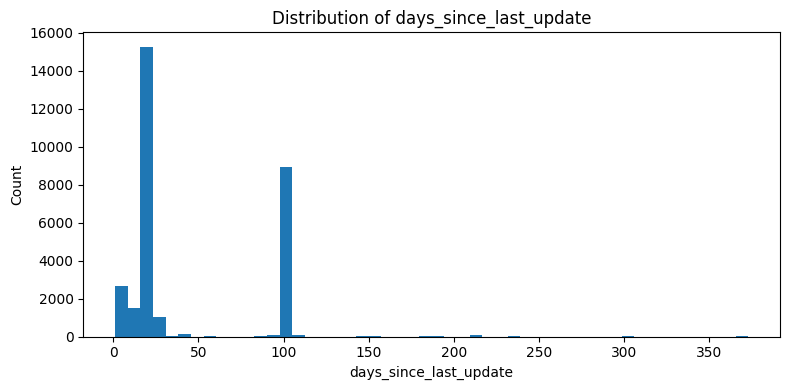

In [3]:
# ============================================================
# 1. Distributions
# ============================================================

import matplotlib.pyplot as plt

distribution_fields = [
    "avg_position",
        "impressions_last_30d",
            "sessions_last_30d",
                "content_age_days",
                    "days_since_last_update",
                    ]

for col in distribution_fields:
                        print(f"\n{'='*60}")
                        print(col)
                        print(df[col].describe())
                        print("Skew:", df[col].skew())

plt.figure(figsize=(8, 4))
plt.hist(df[col].dropna(), bins=50)
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2. Signal test #1 — Search position

**Hypothesis:** Declining observations may show weaker search position than non-declining observations.

**Test:** Compare the mean and median `avg_position` between declining and non-declining observations.

Because lower search-position values represent better rankings, a higher observed position value for declining content would support the hypothesis.

In [15]:
TARGET = "trend_direction"

df["is_declining"] = (
    df[TARGET].astype(str).str.lower() == "down"
    ).astype(int)

print(df["is_declining"].value_counts())

is_declining
1    16262
0    13738
Name: count, dtype: int64


In [16]:
# Signal #1: Search position

position_summary = (
df.groupby("is_declining")["avg_position"]
          .agg(["count", "mean", "median"])
          )

display(position_summary)

declining_median = df.loc[
              df["is_declining"] == 1, "avg_position"
              ].median()

non_declining_median = df.loc[
                  df["is_declining"] == 0, "avg_position"
                  ].median()

if declining_median > non_declining_median:
                      position_verdict = "CONFIRMED"
elif declining_median < non_declining_median:
        position_verdict = "OPPOSITE"
else:
     position_verdict = "MIXED"

print("Signal #1 verdict:", position_verdict)

,count,mean,median
is_declining,,,
0,13738,16.823060,10.05
1,16262,15.936305,11.30


Signal #1 verdict: CONFIRMED


In [29]:
df["is_declining"]

,is_declining
0,1
1,1
2,1
3,0
4,1
...,...
29995,0
29996,1
29997,1
29998,1


## Signal test #2 — Recent impression movement

**Hypothesis:** Declining observations may have weaker recent impression performance relative to the previous 30-day window.

**Test:** Compare the recent-versus-previous 30-day impression change between declining and non-declining observations.

A lower or more negative change for declining observations would support the hypothesis.

In [32]:
# Signal #2: Impression movement

df["impression_change_30d"] = (
    df["impressions_last_30d"] - df["impressions_prev_30d"]
    )

impression_summary = df.groupby("is_declining")["impression_change_30d"].agg(
        count="count",
            mean="mean",
                median="median"
                )

display(impression_summary)

declining_median = df.loc[
                    df["is_declining"] == 1, "impression_change_30d"
                    ].median()

non_declining_median = df.loc[
                        df["is_declining"] == 0, "impression_change_30d"
                        ].median()

print("Declining median impression change:", declining_median)
print("Non-declining median impression change:", non_declining_median)

if declining_median < non_declining_median:
          impression_verdict = "CONFIRMED"
elif declining_median > non_declining_median:
          impression_verdict = "OPPOSITE"
else:
          impression_verdict = "MIXED"

print("Signal #2 verdict:", impression_verdict)

,count,mean,median
is_declining,,,
0,13738,253.042728,3.0
1,16262,-866.861026,-158.0


Declining median impression change: -158.0
Non-declining median impression change: 3.0
Signal #2 verdict: CONFIRMED


## Signal test #3 — Recent session movement

**Hypothesis:** Declining observations may have weaker recent session performance relative to the previous 30-day window.

**Test:** Compare the recent-versus-previous 30-day session change between declining and non-declining observations.

A lower or more negative change for declining observations would support the hypothesis.

In [33]:
# Signal #3: Session movement

df["session_change_30d"] = (
    df["sessions_last_30d"] -
        df["sessions_prev_30d"]
        )
session_summary = (
            df.groupby("is_declining")["session_change_30d"]
                  .agg(["count", "mean", "median"])
                  )

display(session_summary)

declining_median = df.loc[
                      df["is_declining"] == 1,
                          "session_change_30d"
                          ].median()

non_declining_median = df.loc[
                              df["is_declining"] == 0,
                                  "session_change_30d"
                                  ].median()

if declining_median < non_declining_median:
                                      session_verdict = "CONFIRMED"
elif declining_median > non_declining_median:
                                          session_verdict = "OPPOSITE"
else:
                                              session_verdict = "MIXED"

print("Signal #3 verdict:", session_verdict)

,count,mean,median
is_declining,,,
0,13738,5.491993,1.0
1,16262,2.428299,0.0


Signal #3 verdict: CONFIRMED


### Signal verdict summary

The three tests use descriptive comparisons of observed historical data. A `CONFIRMED` verdict means the measured direction matches the stated hypothesis; it does not mean the signal causes decline.

The final interpretation should therefore remain directional and suitable for decision-support rather than causal inference.

## 3. The flag-linked test

The action playbook uses recent impression movement as one of its review signals.

The corresponding rule is:

`impressions_last_30d < impressions_prev_30d`

The test below checks whether observations satisfying this rule have a different observed declining rate from observations that do not satisfy it.

This evaluates whether the rule is directionally supported by the dataset; it does not establish causality.

In [35]:
# Flag-linked test: impression decline

df["impression_decline_flag"] = (
    df["impressions_last_30d"] <
        df["impressions_prev_30d"]
        )

flag_test = (
            df.groupby("impression_decline_flag")["is_declining"]
                  .agg(["count", "mean", "sum"])
                        .rename(columns={
                                  "mean": "declining_rate"
                                        })
                                        )

display(flag_test)

true_rate = df.loc[
                                            df["impression_decline_flag"],
                                                "is_declining"
                                                ].mean()

false_rate = df.loc[
                                                    ~df["impression_decline_flag"],
                                                        "is_declining"
                                                        ].mean()

rate_difference = true_rate - false_rate

print("Declining rate when flag = True :", round(true_rate, 4))
print("Declining rate when flag = False:", round(false_rate, 4))
print("Difference:", round(rate_difference, 4))

if rate_difference > 0:
                                                            flag_verdict = "CONFIRMED"
elif rate_difference < 0:
  flag_verdict = "OPPOSITE"
else:
  flag_verdict = "MIXED"

print("Flag-linked verdict:", flag_verdict)

,count,declining_rate,sum
impression_decline_flag,,,
False,10284,0.000000,0
True,19716,0.824812,16262


Declining rate when flag = True : 0.8248
Declining rate when flag = False: 0.0
Difference: 0.8248
Flag-linked verdict: CONFIRMED


## 4. What this means in practice

The audit provides directional evidence about which historical performance patterns are useful for prioritizing content review. Search position, impression movement, and session movement can be used as supporting signals, while the impression-decline flag can help identify observations that deserve additional investigation.

These signals should be combined with the model output and reason codes rather than treated as standalone causes or guaranteed predictors of future performance.

## Self-check

Before submission, confirm:

- [ ] Distributions of the key fields were inspected.
- [ ] Heavy-tailed or skewed fields were identified from observed distributions.
- [ ] Signal #1 has a mini-test and explicit verdict.
- [ ] Signal #2 has a mini-test and explicit verdict.
- [ ] Signal #3 has a mini-test and explicit verdict.
- [ ] The flag-linked test evaluates a rule used in the action playbook.
- [ ] Verdicts are based on measured data rather than assumptions.
- [ ] Claims use careful language such as observed, measured, directional, and decision-support.
- [ ] No causal claim is made.
- [ ] No client names, private URLs, queries, or credentials are included.
- [ ] The notebook runs top to bottom without errors.
- [ ] The completed notebook is committed under `work/notebooks/`.